In [11]:
import numpy as py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = sns.load_dataset("diamonds")          ############ df
diamonds = sns.load_dataset("diamonds")
tips = sns.load_dataset("tips")
penguins = sns.load_dataset("penguins")
flights = sns.load_dataset("flights")

df.shape

(53940, 10)

In [12]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Matplotlib vs. Pandas vs. Seaborn

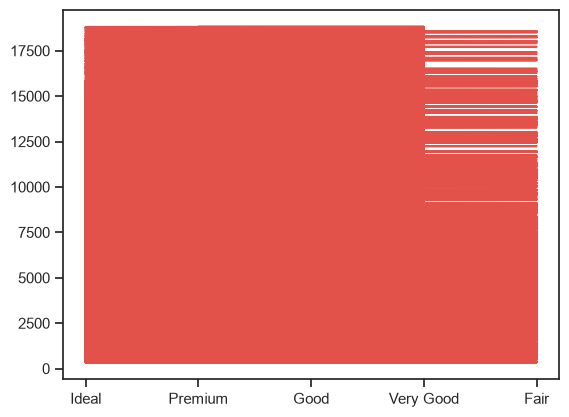

In [13]:
# Matplotlib

# This works but data is not aggregated
plt.plot(df.cut, df.price)
plt.show()

# This is actually a line zig-zagging back and forth

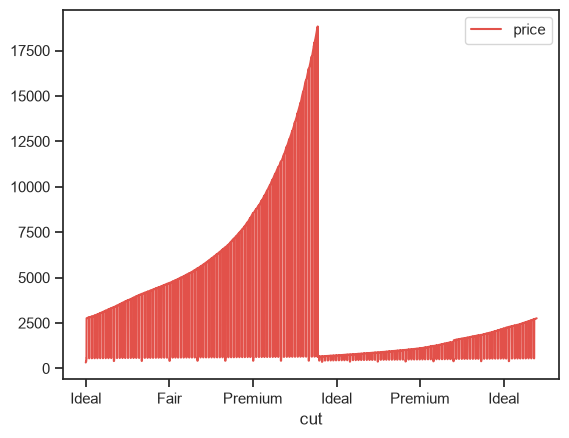

In [14]:
# pandas plot of the same data

df.plot(x='cut', y = 'price')
plt.show()

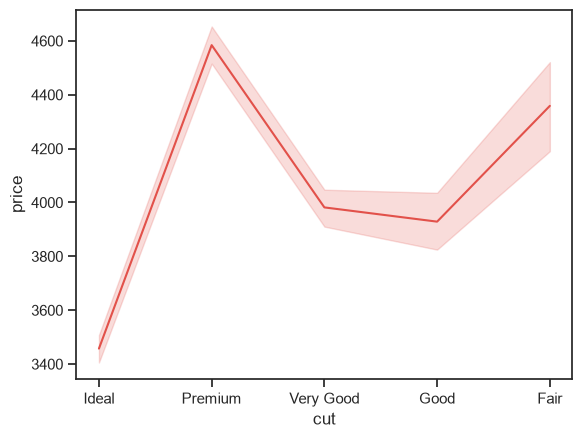

In [15]:
# Seaborn plot of the same data - Automatic grouping
sns.lineplot(data=df, x="cut", y="price")
plt.show()

To get the same result with matplotlib or pandas - the data must be grouped first.

df2 = df.groupby('cut')['price'].mean().reset_index() # creating a smaller dataset


## Seaborn

Seaborn works directly on DataFrames, so mapping a column to color, size, facets, or the x/y axis is one argument each — matplotlib would make you group the data, loop over the groups, and build the legend by hand. It also does statistics as part of drawing: histograms, KDEs, confidence bands, correlation heatmaps, and regression fits come from a single call, where matplotlib expects you to compute those first and plot the results yourself. And its defaults are simply better-looking out of the box, so a presentable chart takes far less fiddling — all while sitting on top of matplotlib, so you keep full low-level control when you need it.

Three cross-cutting capabilities that aren't single functions but belong on any "must-know" list: theming (set_theme(), set_context(), and the palette system via color_palette()), which restyles every plot at once and scales labels for a slide versus a paper; and that axes-level vs. figure-level split, because it decides whether you can drop a plot into an existing subplot grid or whether seaborn owns the whole figure.

### set_theme()
https://seaborn.pydata.org/tutorial/aesthetics.html

In seaborn, a "theme" is the bundle of visual defaults that every plot inherits, and it's really four independent dials that set_theme() sets in one call: style, context, palette, and font.

### set_context()

#### Example: sns.set_context("notebook", font_scale=1.4)  - -  same context, 40% bigger text

set_context is seaborn's answer to one specific question: where is this chart going to be seen? A plot you're squinting at in a notebook, a plot projected on a screen across a lecture hall, and a plot shrunk into a journal column all need the same data drawn with different-sized text and lines. set_context adjusts all of that scaling in one call, without you touching a single font-size argument.

The key idea: it changes the sizing of the annotation layer — tick labels, axis labels, titles, legend text, line widths, marker sizes — but it does not touch the actual data, the colors, or the overall style. It's a zoom dial for the "furniture" of the plot, not the content.

It has four built-in presets, from smallest to largest:

- paper — smallest text and thinnest lines, for a figure that'll be shrunk into a document.
- notebook — the default, tuned for viewing on your own screen at normal size.
- talk — bigger, bolder text and lines, so a chart stays legible on a projected slide.
- poster — biggest of all, for something viewed from a few feet away.

**This is usually bundled into a theme**


### color_palette()

https://seaborn.pydata.org/tutorial/color_palettes.html

The palette is the ordered list of colors seaborn cycles through when a categorical variable is mapped to hue (and it's the default color for single-series plots). Presets include deep (the default), muted, pastel, bright, dark, and — important for accessibility — colorblind. It also accepts any matplotlib colormap name ("viridis") or a custom list.

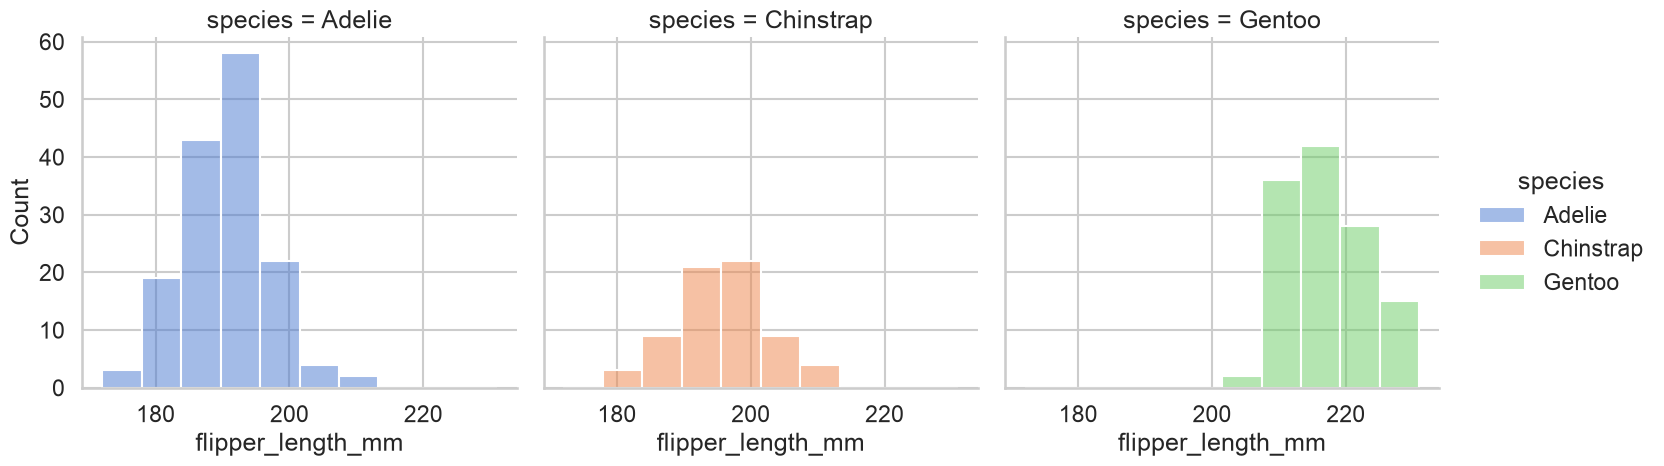

In [16]:

sns.set_theme(style="whitegrid", context="talk", palette="muted")
sns.displot(data=penguins, x="flipper_length_mm", hue="species", col="species")

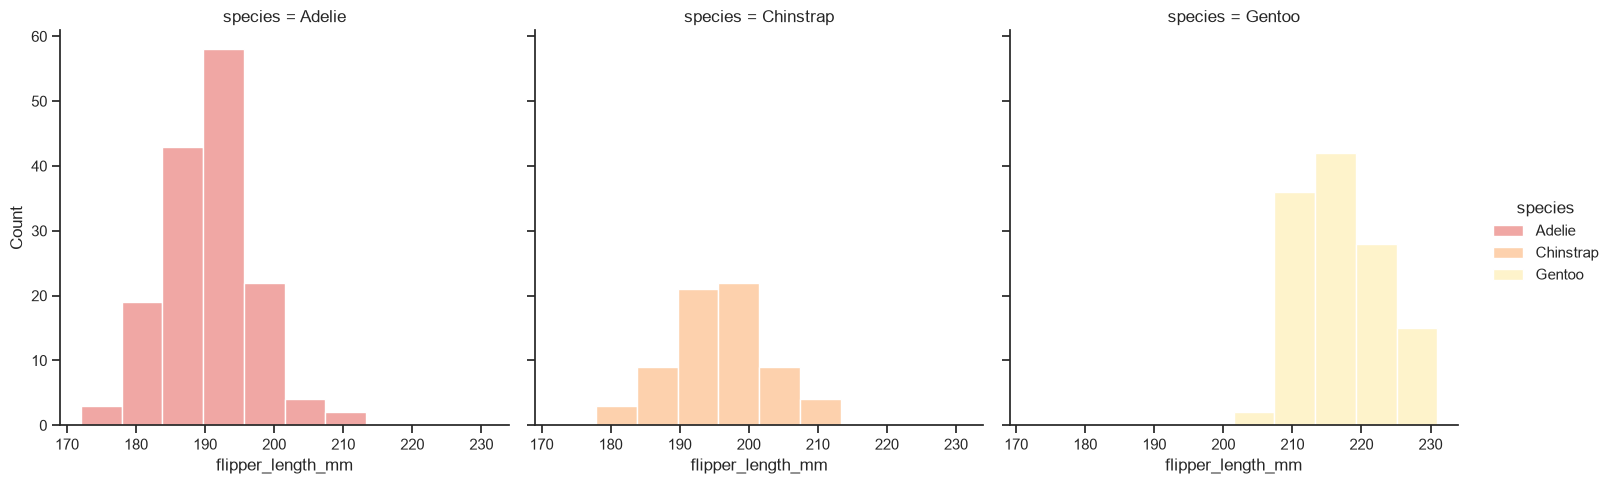

In [17]:
sns.set_theme(style="ticks", context="notebook", palette="Spectral")
sns.displot(data=penguins, x="flipper_length_mm", hue="species", col="species")

## Seaborn Figure level plots

When to use figure level plots:
- facets
- multipanel (jointpot, pairplot)
- want to quickly change plot kinds by changing one word

The figure level plot **owns the whole figure**.  It cannot be dropped into an existing plt.subplots()

So the rule of thumb: reach for figure-level when seaborn should own the layout — faceting, outside legends, shared scales, kind-swapping, or an intrinsically multi-panel chart — and stay axes-level when you own the layout and just want one plot placed exactly where you put it.

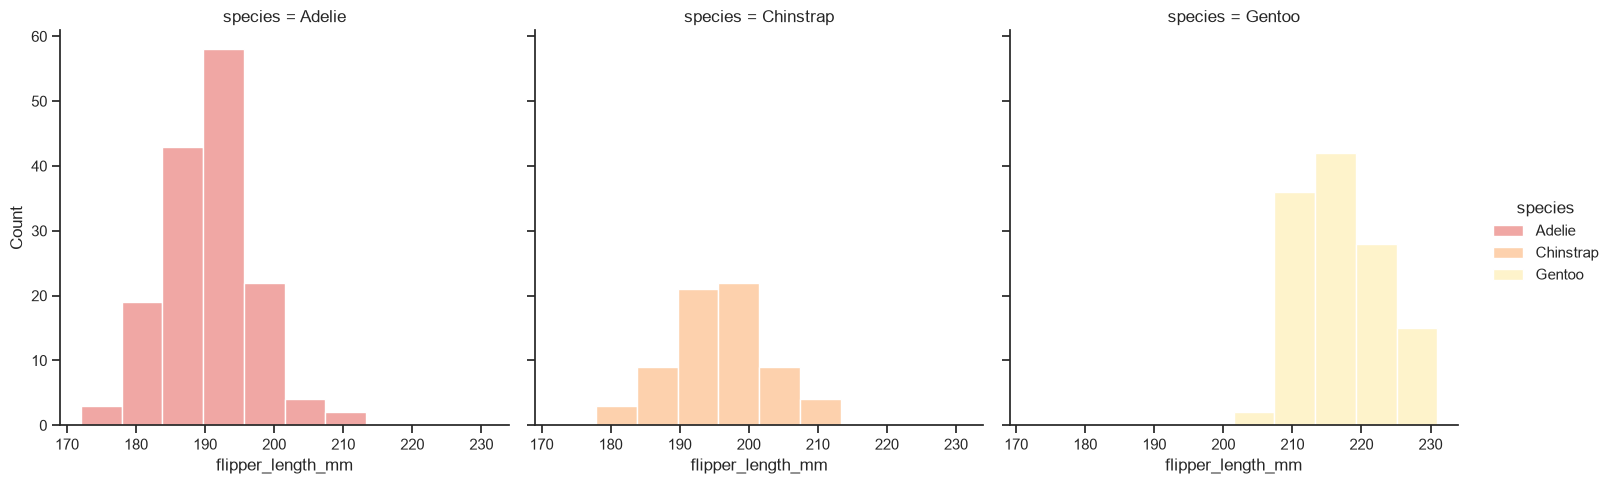

In [18]:
#sns.displot(data=penguins, x="flipper_length_mm", hue="species", multiple="stack", kind='hist')
#sns.displot(data=penguins, x="flipper_length_mm", hue="species", multiple="stack", kind="kde")
sns.displot(data=penguins, x="flipper_length_mm", hue="species", col="species")

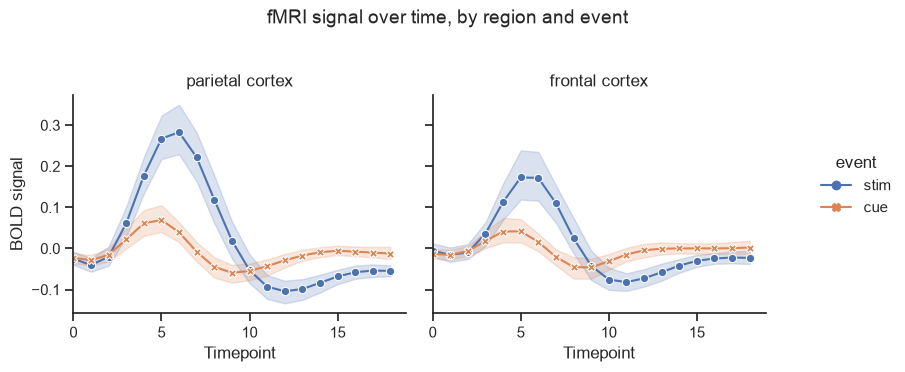

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks", context="notebook")
fmri = sns.load_dataset("fmri")   # tidy/long: subject, timepoint, event, region, signal

g = sns.relplot(
    data=fmri, x="timepoint", y="signal",
    kind="line",                       # sorts by x within each group and connects
    hue="event", style="event",        # color AND dash by event — redundant on purpose (colorblind-safe)
    col="region",                      # facet: one panel per brain region (a *different* variable than hue)
    palette="deep",
    hue_order=["stim", "cue"],         # fix the category order so color/legend are stable
    style_order=["stim", "cue"],
    markers=True, dashes=False,        # markers on, solid lines
    estimator="mean",                  # line-kind collapses repeated y at each x...
    errorbar=("ci", 95),               # ...and shades a 95% CI band (this replaced the old ci= arg)
    n_boot=500,                        # bootstrap resamples behind that band
    height=3.6, aspect=1.15,           # size of each facet (height in inches, width = height*aspect)
    facet_kws=dict(sharey=True, margin_titles=True), # a dctionary of setting passed to each facet
    legend="full",                     # "brief" | "full" | False
)

# relplot is figure-level: it returns a FacetGrid, so customize via g.*, NOT plt.*
g.set_axis_labels("Timepoint", "BOLD signal")
g.set_titles(col_template="{col_name} cortex")
g.figure.suptitle("fMRI signal over time, by region and event", y=1.03, fontsize=14)
g.set(xlim=(0, None))                  # broadcast an axis setting to every facet
g.tight_layout()
plt.show()

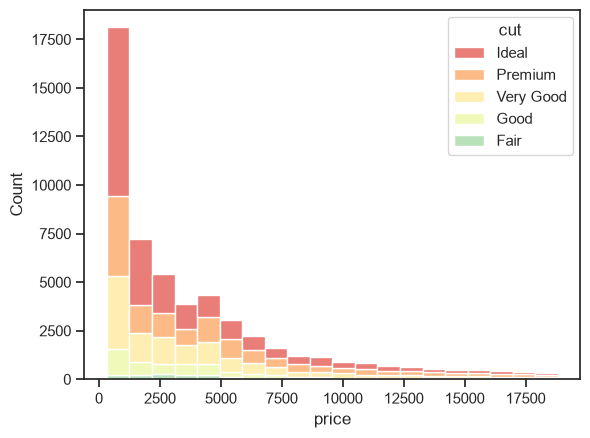

In [21]:
# Axes level
sns.set_theme(style="ticks", context="notebook", palette="Spectral")
sns.histplot(data=df, x='price', hue='cut', multiple = 'stack', bins = 20)
plt.show()

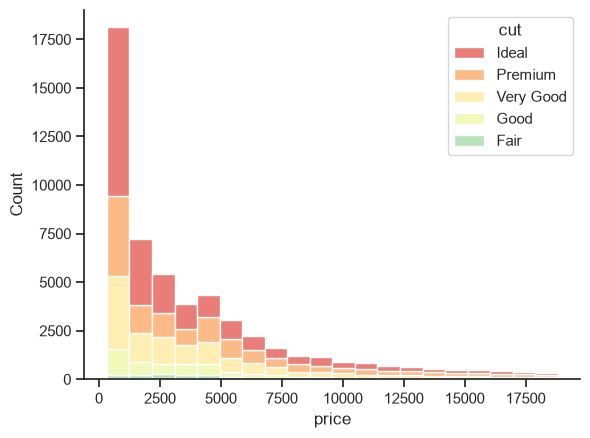

In [22]:
sns.set_theme(style="ticks", context="notebook", palette="Spectral")
sns.histplot(data=df, x='price', hue='cut', multiple = 'stack', bins = 20)

sns.despine()
plt.show()  

### The old subplot method



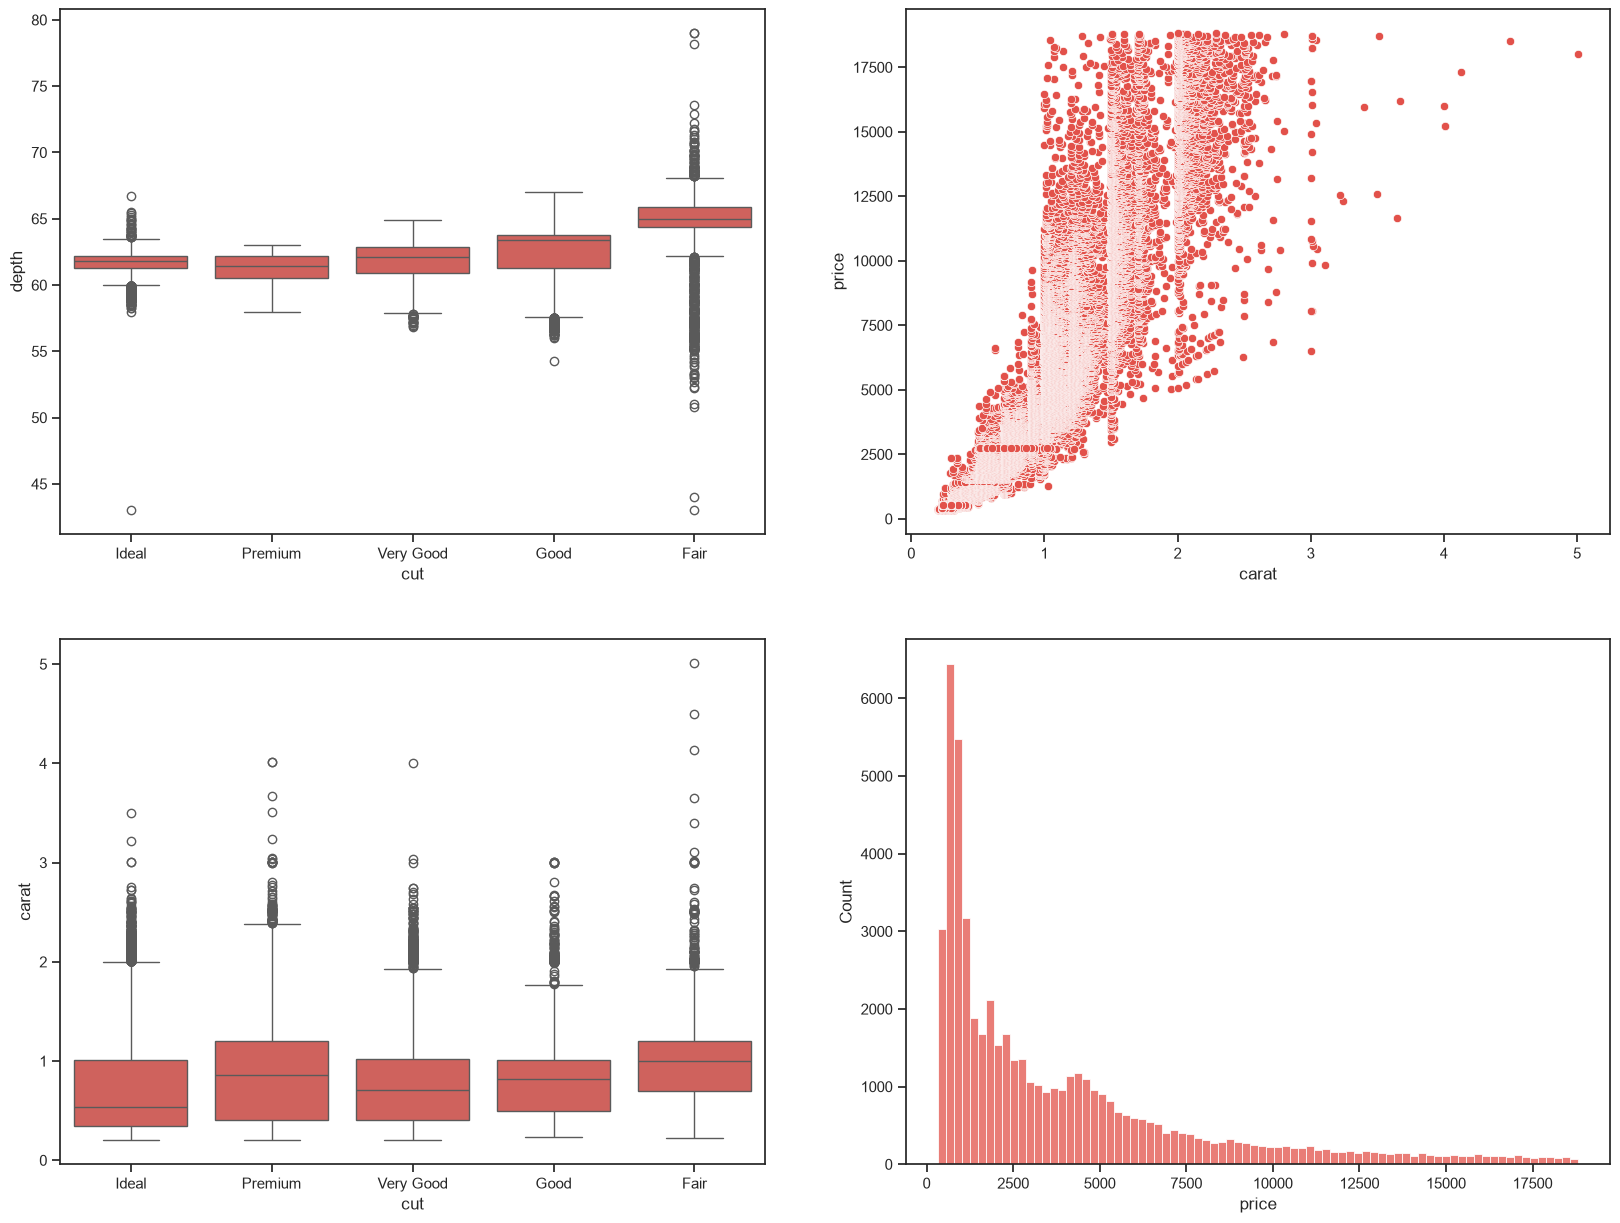

In [23]:
plt.figure(figsize=(20, 15))
plt.subplot(2,2,1)
sns.boxplot(y = 'depth', x = 'cut', data = df)
plt.subplot(2,2,2)
sns.scatterplot(y = 'price', x = 'carat', data = df)
plt.subplot(2,2,3)
sns.boxplot(y = 'carat', x = 'cut', data = df)
plt.subplot(2,2,4)
sns.histplot(x = 'price', data = df)
plt.show()

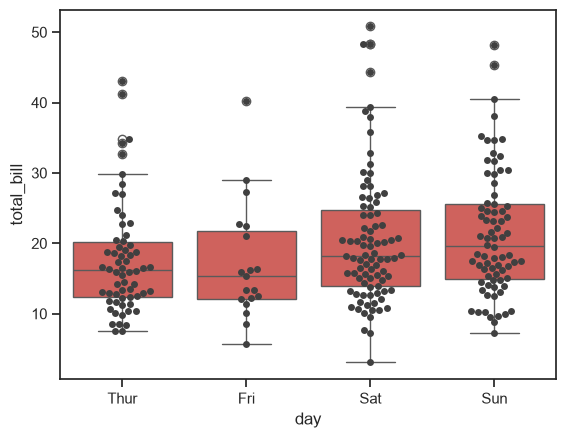

In [27]:
# From Seaborn documentation

# figure is called implicit

ax = sns.boxplot(x="day", y="total_bill", data=tips)
ax = sns.swarmplot(x="day", y="total_bill", data=tips, color=".25")
plt.show()

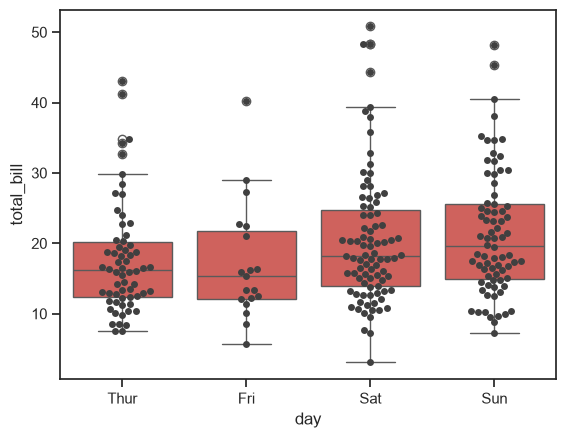

In [26]:
# Better practice - call figure explicitly

fig, ax = plt.subplots()
sns.boxplot(x="day", y="total_bill", data=tips, ax=ax)
sns.swarmplot(x="day", y="total_bill", data=tips, color=".25", ax=ax)
plt.show()